<a href="https://colab.research.google.com/github/Gungun518/AI-ML/blob/main/Worksheet3_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 3: Modelling the Neuron
## MCP Neurons, Perceptron Learning Algorithm & Limitations
---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## TASK 1: MCP Neuron Implementation

In [3]:
# ─────────────────────────────────────────────
# MCP Neuron — AND Gate
# ─────────────────────────────────────────────
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operation using an MCP Neuron for two inputs.

    Arguments:
        X1 (list): Array of binary values.
        X2 (list): Array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): 1 or 0 for each input pair.
    """
    assert len(X1) == len(X2), "X1 and X2 must have the same length."

    # Step 1: Element-wise sum of inputs
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 & 3: Apply threshold — fire if sum >= T
    state_neuron = [1 if s >= T else 0 for s in summed_inputs]

    return state_neuron


# ── Sample Usage ──
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND requires BOTH inputs to be 1 → threshold = 2

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND Gate | Inputs X1={X1}, X2={X2} | Threshold T={T}")
print(f"Output : {result_and}")
print(f"Expected: [0, 0, 0, 1]\n")

AND Gate | Inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | Threshold T=2
Output : [0, 0, 0, 1]
Expected: [0, 0, 0, 1]



In [4]:
# ─────────────────────────────────────────────
# MCP Neuron — OR Gate
# ─────────────────────────────────────────────
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operation using an MCP Neuron for two inputs.

    Arguments:
        X1 (list): Array of binary values.
        X2 (list): Array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): 1 or 0 for each input pair.
    """
    assert len(X1) == len(X2), "X1 and X2 must have the same length."

    # Step 1: Element-wise sum of inputs
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 & 3: Apply threshold — fire if sum >= T
    state_neuron = [1 if s >= T else 0 for s in summed_inputs]

    return state_neuron


# ── Sample Usage ──
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR fires if AT LEAST ONE input is 1 → threshold = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR Gate  | Inputs X1={X1}, X2={X2} | Threshold T={T}")
print(f"Output : {result_or}")
print(f"Expected: [0, 1, 1, 1]")

OR Gate  | Inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | Threshold T=1
Output : [0, 1, 1, 1]
Expected: [0, 1, 1, 1]


---
## Task 1 — Written Questions

### Question 1: Limitations of MCP Neurons

1. **No Learning / Fixed Weights:** MCP neurons have no learnable parameters. All weights are either +1 (excitatory) or -1 (inhibitory) and must be hand-crafted manually. The threshold T also has to be set by hand.
2. **Binary Inputs Only:** MCP neurons accept only binary (0 or 1) inputs. They cannot handle continuous or real-valued data.
3. **Binary Outputs Only:** The output is restricted to 0 or 1. No probabilistic or graded output is possible.
4. **Equal Weights:** All excitatory inputs are treated equally — there is no notion of some inputs being more important than others.
5. **Cannot Solve Non-Linearly Separable Problems:** MCP neurons implement a linear threshold, so they fail on problems like XOR which require a non-linear decision boundary.
6. **No Bias Term:** There is no bias, making it harder to shift the decision boundary.
7. **Biologically Oversimplified:** It ignores time-based dynamics, firing rates, and continuous membrane potentials of real neurons.

---

### Question 2: Can XOR be Solved with a Single MCP Neuron?

**Short Answer: No, a single MCP neuron CANNOT solve XOR.**

**Why?**  
XOR truth table:
| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

For XOR, we need output=1 when sum=1, and output=0 when sum=0 or sum=2.  
A single threshold cannot distinguish sum=1 (fire) from sum=2 (don't fire), because any threshold T that fires for sum≥1 will also fire for sum=2.

**Possible if-else rule attempt (fails):**
```python
# This CANNOT be expressed with a single MCP neuron:
if sum == 1:
    output = 1
else:
    output = 0
# A single threshold cannot capture "exactly equal to 1"
```

**Solution:** XOR requires a **multi-layer** network (at least 2 MCP neurons / a hidden layer), which is why it motivated the development of multi-layer perceptrons (MLPs).

---
## TASK 2: Perceptron for 0 vs 1 Classification (MNIST)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Step 1: Load Dataset
# ─────────────────────────────────────────────
df_0_1 = pd.read_csv("/content/drive/MyDrive/Ai ML/mnist_0_and_1 (1).csv")   # Update path if needed

X = df_0_1.drop(columns=["label"]).values    # Shape: (n_samples, 784)
y = df_0_1["label"].values                   # Shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)


### Question 1: What does the shape of X represent?
**Answer:**  
The shape of `X` is `(n_samples, 784)`.  
- The **first dimension** (`n_samples`) is the total number of images in the dataset.  
- The **second dimension** (`784`) represents the number of pixel features per image — each 28×28 MNIST image has been flattened into a 1D vector of 784 pixel values.

---

### Question 2: What does the shape of y represent?
**Answer:**  
The shape of `y` is `(n_samples,)`.  
It is a 1D array where each element is the **class label** (0 or 1) for the corresponding image in `X`. The index of each label matches the index of its image row in `X`.

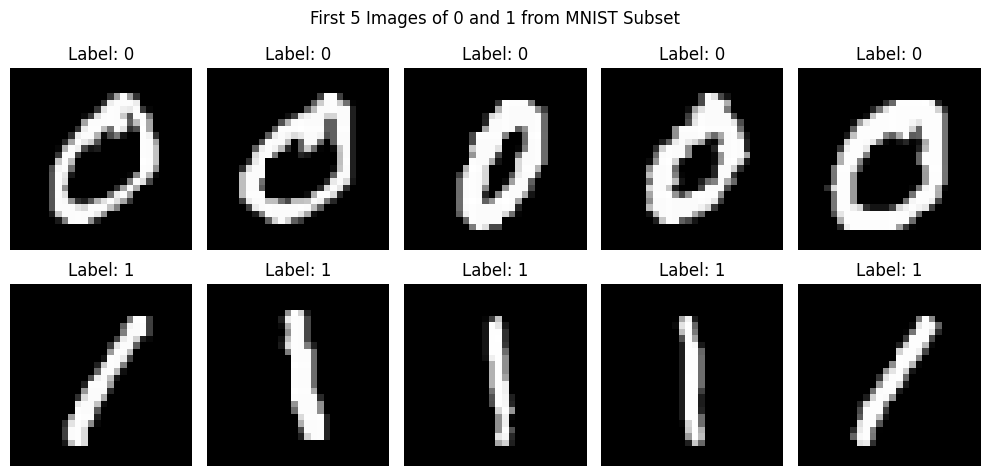

In [6]:
# ─────────────────────────────────────────────
# Step 2: Visualize the Dataset
# ─────────────────────────────────────────────
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot 5 samples.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

In [7]:
# ─────────────────────────────────────────────
# Step 3: Initialize Weights and Bias
# ─────────────────────────────────────────────
weights       = np.zeros(X.shape[1])   # 784 weights — one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f"Weights shape : {weights.shape}")
print(f"Bias          : {bias}")
print(f"Learning Rate : {learning_rate}")
print(f"Epochs        : {epochs}")

Weights shape : (784,)
Bias          : 0
Learning Rate : 0.1
Epochs        : 100


### Question 3: What does the weights array represent?
**Answer:**  
The `weights` array has shape `(784,)` — one weight for each pixel in the 28×28 image.  
Each weight `w_i` represents the **importance/contribution** of the corresponding pixel to the perceptron's final decision. A large positive weight means that pixel strongly pushes toward class 1; a large negative weight pushes toward class 0. During training, these weights are adjusted so that the model learns which pixels are most informative for distinguishing between 0 and 1.

---

### Question 4: Why initialize weights to zero? What effect could this have?
**Answer:**  
**Reason for zero initialization:** It is a simple, neutral starting point that makes no prior assumptions about any feature being more important than others.  

**Effects on training:**  
- For a **single perceptron**, zero initialization is acceptable because the asymmetric update rule (based on misclassification) will break the symmetry and push weights in different directions over time.  
- However, in **multi-layer networks**, zero initialization causes the "symmetry problem" — all neurons compute the same output and receive the same gradient updates, preventing the network from learning diverse features.  
- Zero init may also cause **slow convergence** in early epochs since all initial predictions are identical (all outputs = 0 when all weights = 0), meaning the perceptron only starts learning meaningfully after the first few misclassification-driven updates.

In [8]:
# ─────────────────────────────────────────────
# Step 4: Decision / Activation Function
# ─────────────────────────────────────────────
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step (Heaviside) activation function.

    Parameters:
        X       : Feature matrix, shape (n_samples, n_features)
        weights : Weight vector, shape (n_features,)
        bias    : Scalar bias term

    Returns:
        y_pred_all : Predicted binary labels (0 or 1), shape (n_samples,)
    """
    # Compute weighted sum z = X·w + b
    predictions = np.dot(X, weights) + bias

    # Step / Heaviside activation: output 1 if z >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# Quick sanity check before training
sample_preds = decision_function(X[:5], weights, bias)
print("Sample predictions (before training):", sample_preds)
print("Actual labels                        :", y[:5])

Sample predictions (before training): [1 1 1 1 1]
Actual labels                        : [0 1 1 1 1]


In [9]:
# ─────────────────────────────────────────────
# Step 5: Perceptron Learning Algorithm
# ─────────────────────────────────────────────
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train a Perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : Feature matrix, shape (n_samples, n_features)
        y             : True labels, shape (n_samples,)
        weights       : Initial weight vector, shape (n_features,)
        bias          : Initial scalar bias
        learning_rate : Step size for weight updates (default 0.1)
        epochs        : Number of full passes through the data (default 100)

    Returns:
        weights  : Updated weight vector after training
        bias     : Updated bias after training
        accuracy : Final classification accuracy on training data
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True   # Assume convergence; disprove if any update happens

        for i in range(n_samples):
            # Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Apply step activation
            y_hat = 1 if output >= 0 else 0

            # Update weights only if prediction is wrong
            if y_hat != y[i]:
                error            = y[i] - y_hat            # +1 or -1
                weights         += learning_rate * error * X[i]
                bias            += learning_rate * error
                convergence_flag = False

        # Early stopping if no misclassifications in this epoch
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Compute final training accuracy
    y_pred   = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred == y)

    return weights, bias, accuracy

### Question 5: Purpose of `output = np.dot(X[i], weights) + bias`?
**Answer:**  
This line computes the **net weighted input** (also called the pre-activation or aggregation value) for a single training sample `X[i]`.  
- `np.dot(X[i], weights)` computes the dot product: `w1·x1 + w2·x2 + ... + w784·x784` — a weighted sum of all pixel values.  
- Adding `bias` shifts the decision boundary independently of the input values.  
The resulting scalar `output` is then passed to the step function to produce the binary prediction (0 or 1).

---

### Question 6: What happens when the prediction is wrong? How are weights and bias updated?
**Answer:**  
When `y_hat ≠ y[i]`, the perceptron applies the **Perceptron Learning Rule**:

- **Error** = `y[i] - y_hat` → this is either +1 (predicted 0, true is 1) or -1 (predicted 1, true is 0).  
- **Weight update:** `w_j = w_j + η × error × x_j`  
  - If error = +1: weights increase in the direction of the input, pushing the weighted sum higher next time.  
  - If error = -1: weights decrease, pushing the sum lower next time.  
- **Bias update:** `b = b + η × error`  
  - The bias shifts the entire decision boundary accordingly.

This update nudges the decision boundary in the direction that would have correctly classified this sample.

---

### Question 7: Why is final accuracy important and what do you expect it to be?
**Answer:**  
**Importance:** Final accuracy tells us how well the trained perceptron generalizes on the training data and whether the learning algorithm converged successfully. It is the primary metric for evaluating the model's classification ability.  

**Expected value:** For classifying digits **0 vs 1**, we expect accuracy to be very high — typically **≥ 99%** or even **100%**. This is because 0 and 1 are visually very distinct digits and are **linearly separable** in pixel space, meaning the perceptron (a linear classifier) can perfectly separate them with the right decision boundary.

In [10]:
# ─────────────────────────────────────────────
# Step 6: Train the Perceptron
# ─────────────────────────────────────────────
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"Final Training Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Converged at epoch 13
Final Training Accuracy: 1.0000 (100.00%)


In [11]:
# ─────────────────────────────────────────────
# Step 7: Visualize Misclassified Images
# ─────────────────────────────────────────────
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]} True:{y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


### Question 8: What does `misclassified_idx` store, and how is it used?
**Answer:**  
`misclassified_idx` stores the **integer indices** (row numbers) of all samples in `X` where the perceptron's prediction `y_pred[i]` does not match the true label `y[i]`.  
It is computed using `np.where(y_pred != y)[0]`, which returns the positions where the boolean condition is True.  
These indices are then used to retrieve the corresponding images (`X[idx]`) and plot them so we can **visually inspect which samples were incorrectly classified**, helping diagnose whether the errors are due to ambiguous handwriting, poor image quality, or a fundamental model limitation.

---

### Question 9: How do you interpret "All images were correctly classified!"?
**Answer:**  
This result means the perceptron achieved **100% training accuracy** — it found a linear decision boundary (hyperplane in 784-dimensional space) that perfectly separates all digit-0 images from all digit-1 images.  

**Interpretation:**  
- It confirms that digits 0 and 1 are **linearly separable** in pixel space, which is consistent with the Perceptron Convergence Theorem: if the data is linearly separable, the perceptron is **guaranteed to converge** in a finite number of steps.  
- However, perfect training accuracy does **not** necessarily mean perfect generalization — it would be important to also evaluate on a held-out test set.  
- For 0 vs 1 classification, such a result is expected because the two digit shapes are visually very different.

---
## TASK 3: Perceptron for 3 vs 5 Classification (MNIST)

In [12]:
# ─────────────────────────────────────────────
# Step 1: Load Dataset for 3 vs 5
# ─────────────────────────────────────────────
df_3_5 = pd.read_csv("/content/drive/MyDrive/Ai ML/mnist_3_and_5 (1).csv")   # Update path if needed

X35 = df_3_5.drop(columns=["label"]).values
y35_raw = df_3_5["label"].values

# Re-encode: treat digit 3 as label 0, digit 5 as label 1
y35 = np.where(y35_raw == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape  :", y35.shape)
print("Unique labels       :", np.unique(y35_raw))

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)
Unique labels       : [3 5]


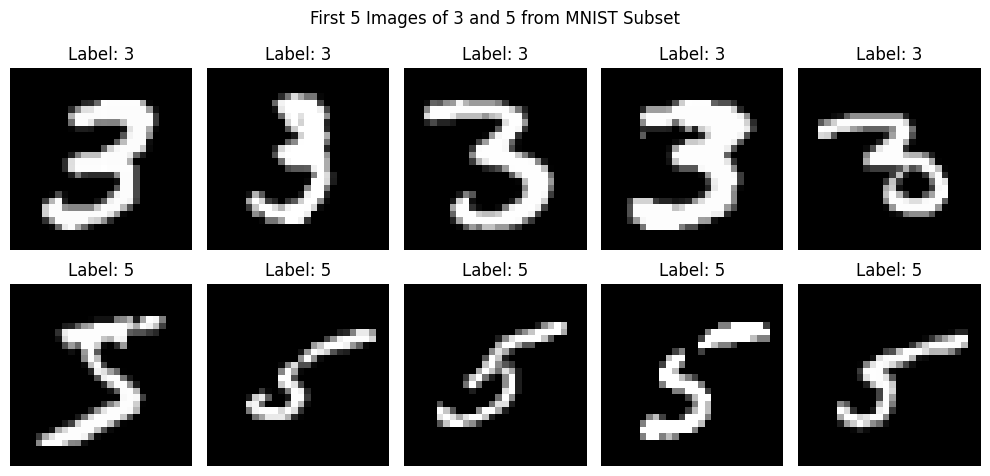

In [13]:
# ─────────────────────────────────────────────
# Step 2: Visualize 3 vs 5
# ─────────────────────────────────────────────
images_3 = X35[y35 == 0]
images_5 = X35[y35 == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────
# Step 3: Initialize Weights, Bias & Hyperparameters
# ─────────────────────────────────────────────
weights35       = np.zeros(X35.shape[1])
bias35          = 0
learning_rate35 = 0.1
epochs35        = 100

print(f"Weights shape : {weights35.shape}")
print(f"Bias          : {bias35}")

Weights shape : (784,)
Bias          : 0


In [15]:
# ─────────────────────────────────────────────
# Step 4 & 5: Reuse decision_function & train_perceptron
# (same functions defined in Task 2 — no changes needed)
# ─────────────────────────────────────────────
weights35, bias35, accuracy35 = train_perceptron(X35, y35, weights35, bias35,
                                                  learning_rate=learning_rate35,
                                                  epochs=epochs35)
print(f"Final Training Accuracy (3 vs 5): {accuracy35:.4f} ({accuracy35*100:.2f}%)")

Final Training Accuracy (3 vs 5): 0.9869 (98.69%)


Final Accuracy (3 vs 5): 0.9869


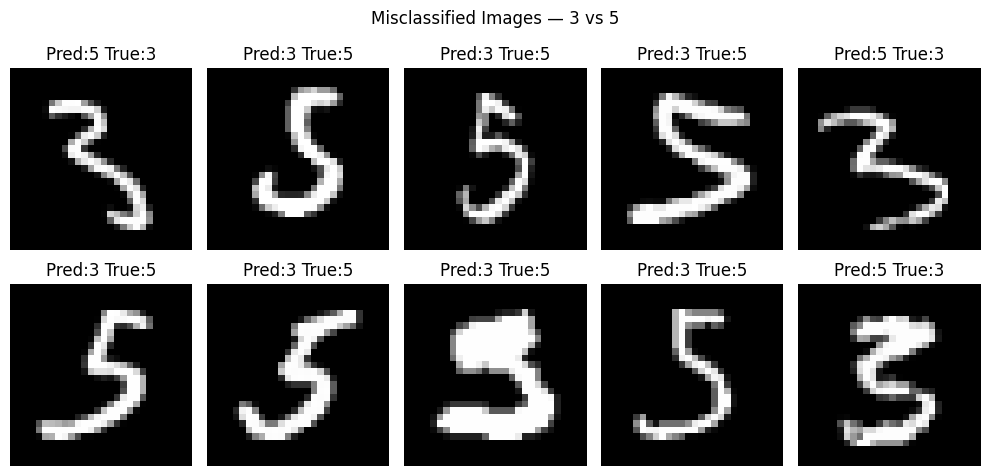

In [16]:
# ─────────────────────────────────────────────
# Step 6: Visualize Misclassified Images for 3 vs 5
# ─────────────────────────────────────────────
predictions35 = np.dot(X35, weights35) + bias35
y_pred35      = np.where(predictions35 >= 0, 1, 0)

final_accuracy35 = np.mean(y_pred35 == y35)
print(f"Final Accuracy (3 vs 5): {final_accuracy35:.4f}")

misclassified_idx35 = np.where(y_pred35 != y35)[0]

if len(misclassified_idx35) > 0:
    n_show = min(10, len(misclassified_idx35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    label_map = {0: 3, 1: 5}   # Map back to original digit labels for display
    for ax, idx in zip(axes.flat, misclassified_idx35[:n_show]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        pred_label = label_map[y_pred35[idx]]
        true_label = label_map[y35[idx]]
        ax.set_title(f"Pred:{pred_label} True:{true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 3 vs 5")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

---
## Task 3 — Conclusion

### Observations:
- The **3 vs 5** classification is significantly **harder** than 0 vs 1.  
- Digits 3 and 5 are **visually similar** — they share curved strokes and similar overall structure, which makes the pixel-space representations overlap more, reducing linear separability.
- As a result, the perceptron is likely to produce **more misclassifications** and may **not converge** within 100 epochs.

### Misclassified Images Analysis:
- Images where 3 is predicted as 5 (and vice versa) tend to be **ambiguously written** — certain handwriting styles make the two digits look nearly identical.
- Since the perceptron is a **linear classifier**, it can only draw a straight hyperplane in pixel space. The 3 vs 5 decision boundary may require a non-linear surface.

### Why the Perceptron Struggles with 3 vs 5:
| Factor | 0 vs 1 | 3 vs 5 |
|--------|--------|--------|
| Visual similarity | Very different | Very similar |
| Linear separability | High (easy) | Lower (harder) |
| Expected accuracy | ~99-100% | ~85-95% |
| Convergence | Fast | Slower / may not converge |

### Key Limitation Highlighted:
> A single-layer perceptron is limited to **linearly separable** problems. For datasets where classes overlap in pixel space (like 3 vs 5), more powerful models such as **Multi-Layer Perceptrons (MLPs)** with non-linear activations (e.g., ReLU, sigmoid) or **Convolutional Neural Networks (CNNs)** are required to achieve high accuracy.